<a href="https://colab.research.google.com/github/anvithagangineni/portfolio/blob/main/PCA_digit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import *

In [2]:
digits=load_digits()
X = pd.DataFrame(digits.data)
y = pd.DataFrame(digits.target)

In [3]:
digits.images[55]

array([[ 0.,  0.,  2., 14., 15.,  5.,  0.,  0.],
       [ 0.,  0., 10., 16., 16., 15.,  1.,  0.],
       [ 0.,  3., 16., 10., 10., 16.,  4.,  0.],
       [ 0.,  5., 16.,  0.,  0., 14.,  6.,  0.],
       [ 0.,  5., 16.,  6.,  0., 12.,  7.,  0.],
       [ 0.,  1., 15., 13.,  4., 13.,  6.,  0.],
       [ 0.,  0., 11., 16., 16., 15.,  0.,  0.],
       [ 0.,  0.,  2., 11., 13.,  4.,  0.,  0.]])

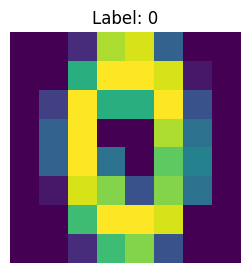

In [4]:
plt.figure(figsize=(3,3))
plt.imshow(digits.images[55])
plt.title(f"Label: { digits.target[55]}")
plt.axis('off')
plt.show()

In [5]:
scalar = StandardScaler()
X_std = scalar.fit_transform(X)

In [6]:
cov_matrix = np.cov(X_std.T)
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

In [7]:
total=sum(eigen_values)

In [8]:
var_exp = [(i/total) * 100 for i in sorted(eigen_values, reverse = True)]
cum_var_exp = np.cumsum(var_exp)

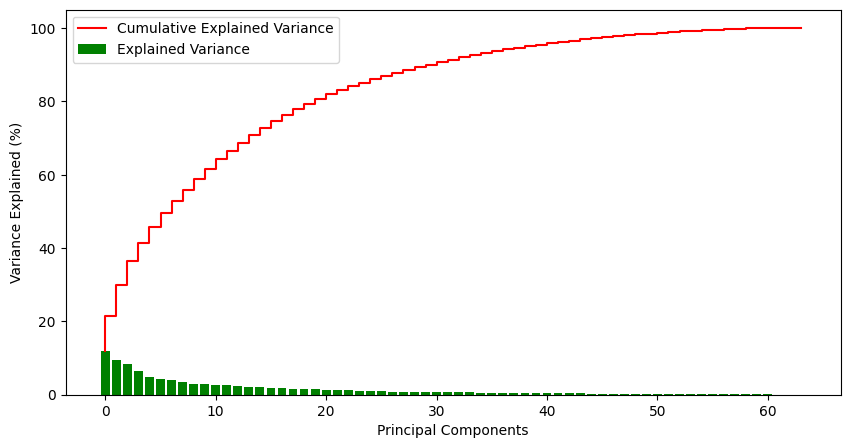

In [9]:
plt.figure(figsize=(10,5))
plt.bar(range(len(var_exp)), var_exp, label="Explained Variance", color='g')
plt.step(range(len(cum_var_exp)), cum_var_exp, label="Cumulative Explained Variance", color='r')
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained (%)")
plt.legend()
plt.show()

In [10]:
x_train,x_test,y_train,y_test=train_test_split(X_std,y,train_size=0.8, random_state=0)

In [11]:
pca = PCA(n_components=20)
pca_x_train = pca.fit_transform(x_train)
pca_x_test = pca.transform(x_test)

In [12]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(pca_x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [13]:
y_pred = clf.predict(pca_x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy after PCA: {round(accuracy*100, 2)}%")

Decision Tree Accuracy after PCA: 81.67%
